<a href="https://colab.research.google.com/github/Nirupama-Halder/Google-Colab-practice-notebooks/blob/main/Problemset_(Advanced)Untitled15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nirupama Halder

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

**Q1** **Research**

In [ ]:
with open("adult.names", "r") as file:
    print(file.read())

| This data was extracted from the census bureau database found at
| http://www.census.gov/ftp/pub/DES/www/welcome.html
| Donor: Ronny Kohavi and Barry Becker,
|        Data Mining and Visualization
|        Silicon Graphics.
|        e-mail: ronnyk@sgi.com for questions.
| Split into train-test using MLC++ GenCVFiles (2/3, 1/3 random).
| 48842 instances, mix of continuous and discrete    (train=32561, test=16281)
| 45222 if instances with unknown values are removed (train=30162, test=15060)
| Duplicate or conflicting instances : 6
| Class probabilities for adult.all file
| Probability for the label '>50K'  : 23.93% / 24.78% (without unknowns)
| Probability for the label '<=50K' : 76.07% / 75.22% (without unknowns)
|
| Extraction was done by Barry Becker from the 1994 Census database.  A set of
|   reasonably clean records was extracted using the following conditions:
|   ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))
|
| Prediction task is to determine whether a person makes over

##Research
**Capital_gain**: Capital-gain refers to the profit earned from selling assets or investments.
Examples include stocks, property, and mutual funds.
People may have to pay tax on this profit.
Not everyone has capital-gain, so many values can be zero.
Some people have very high investment profits, which creates extreme values in the dataset.


**Capital_loss:** refers to the loss incurred from selling assets or investments.
Loss occurs when an asset is sold at a lower price than its purchase price.
Capital-loss is used in tax calculations.
Most people have zero capital-loss values.
A few people may have very large losses.

**Q1**(**Theory** **1**)

In [ ]:
display(df.describe())
df['capital_gain'].value_counts()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


,count
capital_gain,
0,29849
15024,347
7688,284
7298,246
99999,159
...,...
6097,1
1639,1
7978,1


Text(0.5, 1.0, 'Capital Gain of histplot')

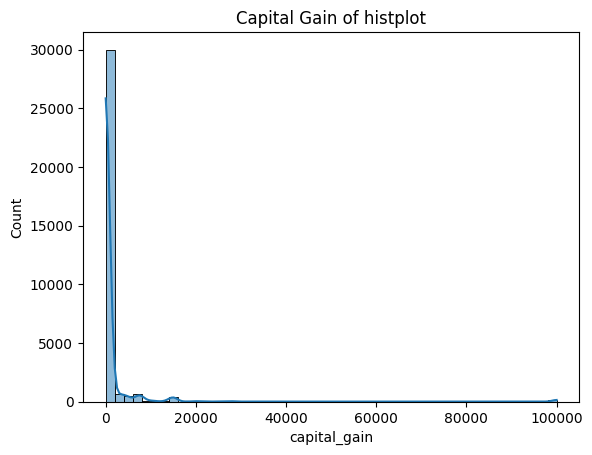

In [ ]:
sns.histplot(data=df, x='capital_gain',bins = 50,kde = True)
title = 'Capital Gain of histplot'
plt.title(title)

**Histplot**: we can see that the hisplot does not follow a normal distribution. The histplot is highly right-skewed. Most values are near zero and few values are very large.

Text(0.5, 1.0, 'Capital Gain of boxplot')

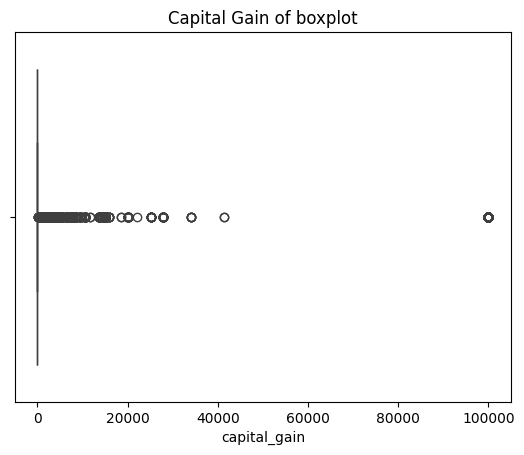

In [ ]:
sns.boxplot(data=df, x='capital_gain')
title = 'Capital Gain of boxplot'
plt.title(title)

**Boxplot**: From the boxplot we can see that the most of the values are concentrated near zero, while a few values are extremely high and appaer as outliers.

**Theory** **1**:


This is mainly a distribution problem rather than only an outlier problem. Although the column contains extreme outlier values,around 91% of the values are exactly zero, which makes the distribution highly right-skewed and non-normal. A normal distribution should be symmetric and bell-shaped, but the capital_gain column is near zero with a few extremely large values.

**Q1** (**Theory** **2**)

In [ ]:
ss = StandardScaler()
StandardScaler = ss.fit(X_train[['capital_gain']])
X_train['capital_gain_standard'] = ss.transform(X_train[['capital_gain']]).ravel()
X_test['capital_gain_standard'] = ss.transform(X_test[['capital_gain']]).ravel()
#X_train.sample(5)
print(round(X_train['capital_gain_standard'].mean()))
round(X_train['capital_gain_standard'].std())


0


1

,capital_gain_standard
count,2.604800e+04
mean,1.854918e-17
std,1.000019e+00
min,-1.449799e-01
25%,-1.449799e-01
50%,-1.449799e-01
75%,-1.449799e-01
max,1.357022e+01


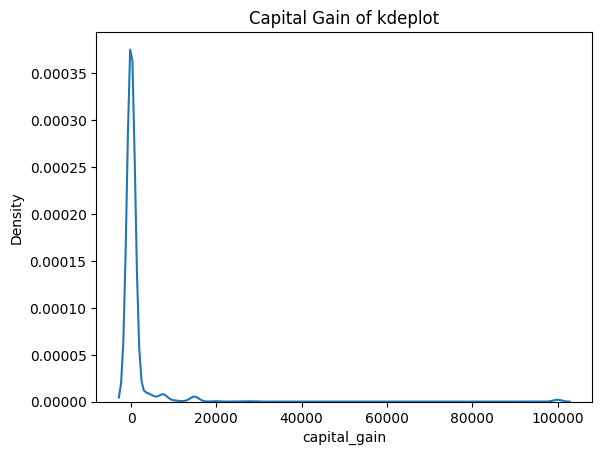

In [ ]:
sns.kdeplot(data=X_train, x='capital_gain')
title = 'Capital Gain of kdeplot'
plt.title(title)
X_train['capital_gain_standard'].describe()

In [ ]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
rs.fit(X_train[['capital_gain']])
X_train['capital_gain_robust'] = rs.transform(X_train[['capital_gain']]).ravel()
X_test['capital_gain_robust'] = rs.transform(X_test[['capital_gain']]).ravel()

display(X_train['capital_gain_robust'].describe())


,capital_gain_robust
count,26048.000000
mean,1057.064266
std,7291.248814
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


**Theory** **2**:


After applying StandardScaler(Zscore normalization), the 25th, 50th, and 75th percentile values became approximately -0.145. This happened because StandardScaler uses the mean and standard deviation, which are strongly influenced by extreme values. As a result, the outliers had a significant impact on the scalling procces.

From the descriptive statistics, the 25th , 50th and 75th percentiles of the capital_gain column are all zero. This indicate that most of the values in the column are zero and the distribution is highly right-skewed.

RobustScaler is generally more appropriate for such skewed data because it uses the median and Interquartile Range(IQR) instead of the mean and standard deviation. Therefore, it is less sensitive to extreme values and outliers. However, in the dataset, the effect of RobustScaler was not very noticeable because the IQR is effectively zero due to the large number of zero values.

**Q1** (**Theory** **3**)

**Winsorization**

Winsorization is a technique used to reduce the effect of outliers. Instead of removing extreme values, it replaces them with values from a chosen percentile range. Instead, values below the lower percentile threshold are replaced with the lower percentile value, and values above the upper percentile threshold are replaced with the upper percentile value. This reduces the impact of outliers while preserving all abservations in the dataset.



In [ ]:
X_train['hours_per_week'].describe()


,hours_per_week
count,26048.000000
mean,40.281749
std,10.219763
min,18.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,60.000000


In [ ]:
x = 5
x = x/100
min_range = X_train['hours_per_week'].quantile(0.05)
max_range = X_train['hours_per_week'].quantile(0.95)
print(f'min_range: {min_range}')
print(f'max_range: {max_range}')


min_range: 18.0
max_range: 60.0


In [ ]:
X_train['hours_per_week'] = X_train['hours_per_week'].clip(min_range,max_range)
X_test['hours_per_week'] = X_test['hours_per_week'].clip(min_range,max_range)
X_train['hours_per_week'].describe()

,hours_per_week
count,26048.000000
mean,40.281749
std,10.219763
min,18.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,60.000000


**Theory** **3**:

winsorization is an outlier treatment technique that does not remove extreme values. instead, values below the lower percentile threshold are replaced with the lower percentile value and values above the upper percentile threshold are replaced with the upper percentile value. This reduces the impact of outliers while preserving all observations in the dataset.

For the hours_per_week column, the 5th percentile is 18 and the 95th percentile is 60. Applying 5th-95th percentile winsorization means that values below 18 would be replaced with 18, and values above 60 would be replaced with 60.


This assumes that extremely low and extremely high working hours are usually observations and do not represent the typical data-generating process.

The risk is that some of these extreme values may be genuine observations. Replacing them can remove important information and may distort the true distribution of the data.


**Q1** (**Practical** **Q4**)


Load the dataset, handle missing values, and perform train-test split

In [ ]:
#load the dataset
df = pd.read_csv('adult.data')



In [ ]:
df.shape
len(df.columns)

15

In [ ]:
df.columns = ['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
#train_test_split
X = df.drop(columns=['income'])
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((26048, 14), (6512, 14))

In [ ]:
#Handle missing values
display(X_train.isnull().sum())
display(X_test.isnull().sum())
display(y_train.isnull().sum())
display(y_test.isnull().sum())

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


np.int64(0)

np.int64(0)

Text(0.5, 1.0, 'Capital Gain of kdeplot')

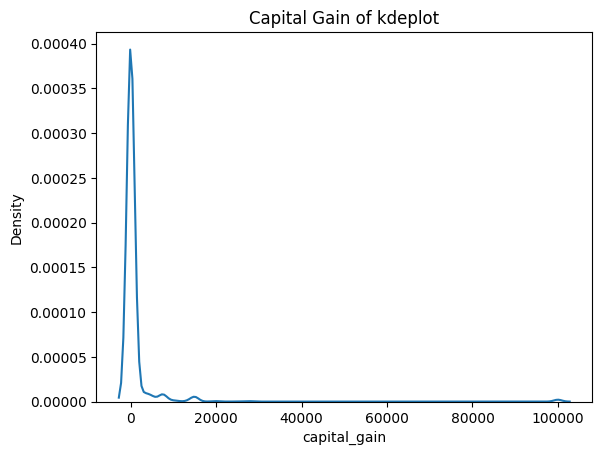

In [ ]:
sns.kdeplot(data=df, x='capital_gain')
title = 'Capital Gain of kdeplot'
plt.title(title)

**Practical** **Q4**

**Observation**:

The KDEplot shows that the capital_gain features is highly right-skewed. Most observations are concentrated near 0, while a few values extend far to the right, indicating the presence of extreme values.

**Q1** (**Practical** **Q5**)

  Apply Winsorization (5th–95th percentile) to capital-gain

In [ ]:
x = 5
x = x/100
min_range = X_train['capital_gain'].quantile(0.05)
max_range = X_train['capital_gain'].quantile(0.95)
print(f'min_range: {min_range}')
print(f'max_range: {max_range}')


min_range: 0.0
max_range: 4865.0


Text(0.5, 1.0, 'Capital Gain of kdeplot')

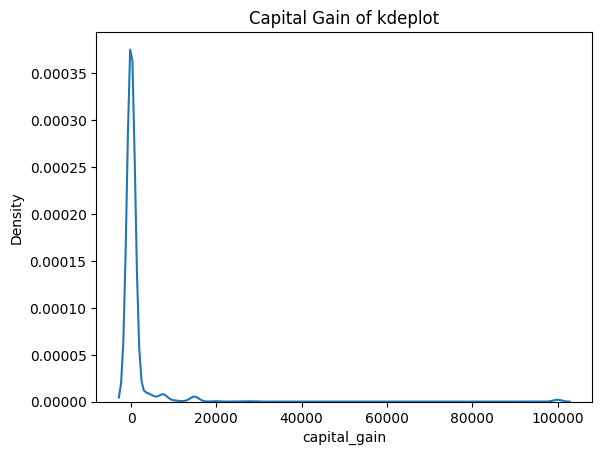

In [ ]:
#KDEplot before clipping
sns.kdeplot(data=X_train, x='capital_gain')
title = 'Capital Gain of kdeplot'
plt.title(title)

In [ ]:
X_train['capital_gain'] = X_train['capital_gain'].clip(min_range,max_range)
X_test['capital_gain'] = X_test['capital_gain'].clip(min_range,max_range)
X_train['capital_gain'].describe()

,capital_gain
count,26048.000000
mean,343.243397
std,1185.798541
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4865.000000


Text(0.5, 1.0, 'Capital Gain of kdeplot')

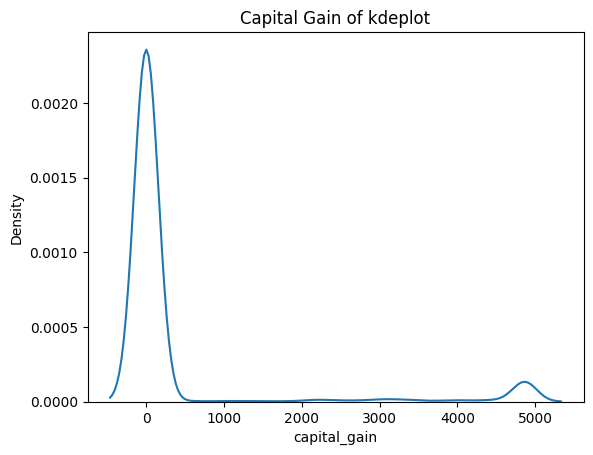

In [ ]:
#KDEplot after clipping
sns.kdeplot(data=X_train, x='capital_gain')
title = 'Capital Gain of kdeplot'
plt.title(title)

**Practical** **Q5**

**Observation**:

After winsorization, the extreme values were capped at the 95th percentile. The right tail became shorter, reducing the influence the outliers while preserving all observations.

**Q1** (**practical** **Q6**)

Apply RobustScaler to hours-per-week and capital-gain

In [ ]:
rs = RobustScaler()
rs.fit(X_train[['capital_gain','hours_per_week']])
X_train[['capital_gain_robust','hours_per_week_robust']] = rs.transform(X_train[['capital_gain','hours_per_week']])
X_test[['capital_gain_robust','hours_per_week_robust']] = rs.transform(X_test[['capital_gain','hours_per_week']])

display(X_train[['capital_gain_robust','hours_per_week_robust']].describe())

,capital_gain_robust,hours_per_week_robust
count,26048.000000,26048.000000
mean,1057.064266,0.090441
std,7291.248814,2.471795
min,0.000000,-7.800000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,1.000000
max,99999.000000,11.800000


In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
StandardScaler = ss.fit(X_train[['capital_gain','hours_per_week']])
X_train[['capital_gain_standard','hours_per_week_standard']] = ss.transform(X_train[['capital_gain','hours_per_week']])
X_test[['capital_gain_standard','hours_per_week_standard']] = ss.transform(X_test[['capital_gain','hours_per_week']])
#X_train.sample(5)
print(round(X_train[['capital_gain_standard','hours_per_week_standard']].mean()))
round(X_train[['capital_gain_standard','hours_per_week_standard']].std())
X_train[['capital_gain_standard','hours_per_week_standard']].describe()



capital_gain_standard      0.0
hours_per_week_standard    0.0
dtype: float64


,capital_gain_standard,hours_per_week_standard
count,2.604800e+04,2.604800e+04
mean,1.854918e-17,2.992419e-16
std,1.000019e+00,1.000019e+00
min,-1.449799e-01,-3.192252e+00
25%,-1.449799e-01,-3.658980e-02
50%,-1.449799e-01,-3.658980e-02
75%,-1.449799e-01,3.679823e-01
max,1.357022e+01,4.737361e+00


**Practical** **Q6**


**Observation** **and** **Compare**


After applying StandardScaler, the maximum scaled values were approxmately 13.57 for capital_gain and 4.74 for hours_per_week.

After applying RobustScaler, the maximum scaled values were approxmately 99999 for capital_gain and 11.80 for hours_per_week. The capital_gain values remaind largely unchanged because the features contains a large number of zeros, resulting in median of 0 and an IQR based scaled of 1.


Therefor, in this dataset, standardscaler produced a much smaller scaled range for capital_gain, while RobustScaler had little effect on that features. However, RobustScaler is generally preferred for skewed data with outliers because it relies on the median and IQR rather than the mean and standard diviation.



**SURPRISE** **BONUS** **CHALLENGE**:


The End-to-End Pipeline Challenge

In [ ]:
# numerical and categorical column create
numerical_columns = X_train.select_dtypes(include=np.number).columns
categorical_columns = X_train.select_dtypes(exclude=np.number).columns

In [ ]:
# numerical and categorical pipeline create
numerical_pipeline = Pipeline([
    ('numerical_column', SimpleImputer(missing_values = np.nan,strategy='mean')),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('categorical_column', SimpleImputer(missing_values = np.nan,strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output = False))

])

#column_transformer
imputer_transformer = ColumnTransformer(
    transformers = [
        ('numerical', numerical_pipeline, numerical_columns),
        ('categorical', categorical_pipeline, categorical_columns)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

imputer_transformer.set_output(transform='pandas')
imputer_transformer.fit(X_train)
X_train_transformed = imputer_transformer.transform(X_train)
X_test_transformed = imputer_transformer.transform(X_test)
print(X_train_transformed.shape)
print(X_test_transformed.shape)
display(X_train_transformed.head())
display(X_train_transformed.describe())
X_train_transformed.columns

(26048, 112)
(6512, 112)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,capital_gain_robust,hours_per_week_robust,capital_gain_standard,hours_per_week_standard,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
24639,-0.85,1.745175,-0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5514,-0.80,-0.314678,0.000000,0.0,0.0,-5.6,0.0,-5.6,0.0,-5.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19777,1.35,1.131088,0.000000,0.0,0.0,-7.4,0.0,-7.4,0.0,-7.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10781,-0.55,0.416518,-0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32239,-0.80,0.017731,0.333333,0.0,0.0,1.2,0.0,1.2,0.0,1.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,capital_gain_robust,hours_per_week_robust,capital_gain_standard,hours_per_week_standard,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
count,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,...,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,0.078240,0.096807,0.023086,343.243397,87.328893,0.090441,1057.064266,0.090441,0.144980,0.090441,...,0.001190,0.003340,0.000346,0.002572,0.001459,0.000614,0.000576,0.895424,0.002073,0.000461
std,0.682951,0.892822,0.854681,1185.798541,402.503406,2.471795,7291.248814,2.471795,1.000019,2.471795,...,0.034478,0.057697,0.018585,0.050652,0.038168,0.024777,0.023991,0.306012,0.045485,0.021459
min,-1.000000,-1.397911,-3.000000,0.000000,0.000000,-7.800000,0.000000,-7.800000,0.000000,-7.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.450000,-0.508385,-0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.550000,0.491615,0.666667,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2.650000,11.016365,2.000000,4865.000000,4356.000000,11.800000,99999.000000,11.800000,13.715198,11.800000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week', 'capital_gain_robust', 'hours_per_week_robust',
       'capital_gain_standard', 'hours_per_week_standard',
       ...
       'native_country_ Portugal', 'native_country_ Puerto-Rico',
       'native_country_ Scotland', 'native_country_ South',
       'native_country_ Taiwan', 'native_country_ Thailand',
       'native_country_ Trinadad&Tobago', 'native_country_ United-States',
       'native_country_ Vietnam', 'native_country_ Yugoslavia'],
      dtype='object', length=112)